# 数据压缩入门：教师演示

45分钟核心课。先预测，再按教师指令运行当前单元。不要提前运行全部单元。

需求：Python 3.10+、JupyterLab、Pillow；IPython由Jupyter提供。离线可运行，不需要widgets。整个课程目录一起复制。

教师控制：Q1隐藏精确比较，Q3才揭示；A1私有颜色卡只给发送者。Q5先收方案，再给A2。第40分钟进入Q10。失败20秒用PPTX静态页。课前清空全部输出。

## 知识导航

数据压缩有四条待回答的主枝：为何压缩、怎样变小、能否恢复、怎样选择。Q4、Q7、Q9之后整理一次，Q10后检查完整知识树。先不要填写尚未得到证据的结论。

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Image, HTML
here = Path.cwd().resolve()
candidates = [here, here / "1-2-encoding/1-2-4-data-compresson", *here.parents]
ROOT = next((p for p in candidates if (p / "demos/compression_lab.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请将整个课程文件夹复制到本机，并从该文件夹打开Notebook")
sys.path.insert(0, str(ROOT / "demos"))
from compression_lab import (COLORS, ALTERNATING, GRAY, rle_encode, rle_decode,
    named_runs, opening, predictive, approximate, image_evidence, save_jpeg_trial,
    video_changes, show_comparison_pair, photo_evidence)
def show(name, width=384):
    display(Image(filename=str(ROOT / "assets/evidence" / name), width=width))
print("准备完成。按教师指令逐格运行，先写预测。")

准备完成。按教师指令逐格运行，先写预测。


## Q1 文件变小，是不是删掉了内容？ · D1

图中有哪些内容可能变化？写下你想检查的对象。

预测／观察：________________

证据／判断：________________

**教师备课与预期结果**

4096B→本机实际输出（随包为38B）。本阶段只观察外观，opening(True)留到Q3。不要把两PNG文件大小当颜色数据量。

先运行：原图与数据量。

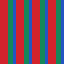

{'输入数据B': 4096, '编码数据B': 38}

In [20]:
show("opening-original.png", 256)
opening(reveal=False)

收到预测后：只显示读回图，暂不检验精确相等。

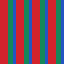

In [21]:
show("opening-restored.png", 256)

## Q2 连续重复的颜色，怎样少写一些？ · D2

发送者看私有颜色卡。记录规则、短消息、接收者还原结果；比较后再运行。

预测／观察：________________

证据／判断：________________

**教师备课与预期结果**

共享例红8绿5蓝3，payload 16B→6B。编号与次数各1B，双方预先共享规则。私有原串只给发送者，避免凭记忆还原。

活动后运行编码。

In [4]:
encoded = rle_encode(COLORS)
print(named_runs(encoded))
print("编码的bytes：", list(encoded))

红8  绿5  蓝3
编码的bytes： [1, 8, 2, 5, 3, 3]


先预测还原，再运行。

In [5]:
restored = rle_decode(encoded)
print("颜色顺序：", [int(v) for v in restored])

颜色顺序： [1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3]


## Q3 少写以后，怎样证明一个也没丢？ · D1

提出一个精确检验方法。应比较哪两个对象？

预测／观察：________________

证据／判断：________________

**教师备课与预期结果**

4096B读回与输入逐byte一致。不能比较压缩bytes和原bytes，也不能仅看长度或外观。此时揭示无损定义。

核对方法后运行。

In [6]:
print("RLE读回与输入一致：", rle_decode(rle_encode(COLORS)) == COLORS)
opening(reveal=True)

RLE读回与输入一致： True


{'输入数据B': 4096, '编码数据B': 38, '解压数据B': 4096, '解压结果与原输入逐byte一致': True}

## Q4 同一规则，为什么有时反而变大？ · D2

两串都是16B；相同连续段规则，哪串更省？先数段，再运行。

预测／观察：________________

证据／判断：________________

**教师备课与预期结果**

16B→6B与16B→32B均能准确还原。无损不保证所有输入变小。不要把交替串改成红8绿8。

运行两组比较。

In [7]:
for name, data in [("连续段", COLORS), ("红绿交替", ALTERNATING)]:
    result = rle_encode(data)
    print(name, "输入", len(data), "B；编码", len(result), "B；读回一致", rle_decode(result) == data)

连续段 输入 16 B；编码 6 B；读回一致 True
红绿交替 输入 16 B；编码 32 B；读回一致 True


### 阶段小结：Q4之后

先不用术语，说出少写的办法、核对的方法和可能的代价。

这组问题让我学会：________________

对应主枝：为何压缩／怎样变小／能否恢复／怎样选择（圈选）。

教师控制：先留8秒收学生归纳，再显示已学节点；30秒计入当前Q预算。无损不保证每份数据都变小。

![此时已学知识树，红框为本轮新增节点。](assets/knowledge/tree-1.png)

## Q5 相邻值不相同，还能利用它们的关系吗？ · D3

原值120,121,122,121,120,120,121,122。先提规则，再填A2差值、读回末三项。

预测／观察：________________

证据／判断：________________

**教师备课与预期结果**

起点8bit＋7×2bit=22bit，装3B补2bit。−1=00，0=01，+1=10。长度、模式、码表未计入。差值没有少项；大差值拒绝，不能推广任意图像。

完成表后运行。

In [8]:
values = list(GRAY)
predictive(values)

{'起点': 120,
 '差值': [1, 1, -1, -1, 0, 1, 1],
 '有效bit': 22,
 'payload_B': 3,
 '补位bit': 2,
 '读回': [120, 121, 122, 121, 120, 120, 121, 122],
 '完整恢复': True}

可选：学生提议出现大差值时，先预测能否使用本码表。

In [9]:
try:
    print(predictive([120, 150]))
except ValueError as error:
    print(error)

本课2bit码表只接受−1、0、＋1；此输入需其他编码


## Q6 只留近似值，还能找回原数吗？ · D4

归最近的4的倍数，中点向上、上限252。写两个能恢复为120的原数。

预测／观察：________________

证据／判断：________________

**教师备课与预期结果**

120与121同归120。8×6=48bit=6B，还原120,120,124,120,120,120,120,124。此模型不是JPEG，不与初次采样量化混同。

完成A2近似表后运行。

In [10]:
approximate(GRAY)

{'原值': [120, 121, 122, 121, 120, 120, 121, 122],
 '等级编号': [30, 30, 31, 30, 30, 30, 30, 31],
 '代表值': [120, 120, 124, 120, 120, 120, 120, 124],
 '有效bit': 48,
 'payload_B': 6,
 '完整恢复': False}

先将你想到的两个原数填入列表，再检验。

In [11]:
candidate_values = []  # 填你想到的两个原数
if len(candidate_values) == 2:
    display(approximate(candidate_values))
else:
    print("先填两个原数，再运行检验。")

先填两个原数，再运行检验。


## Q7 看起来差不多，能否叫无损？ · D5

先比较中性A/B，再写：看不出变化足以证明数据相同吗？

预测／观察：________________

证据／判断：________________

**教师备课与预期结果**

绘画图像以所提供JPEG本次解码RGB为起点，1020×1500。PNG1706860B/像素一致；JPEGq80 240848B/504742像素改变；q20 73692B/1520212像素改变。本次RGB4590000B，不证明更早原图无损。裁切192×128、最近邻放大4倍。程序测试图PNG4441B、JPEG10766B，大小关系相反。quality不是质量百分比。

只看图，先收判断。


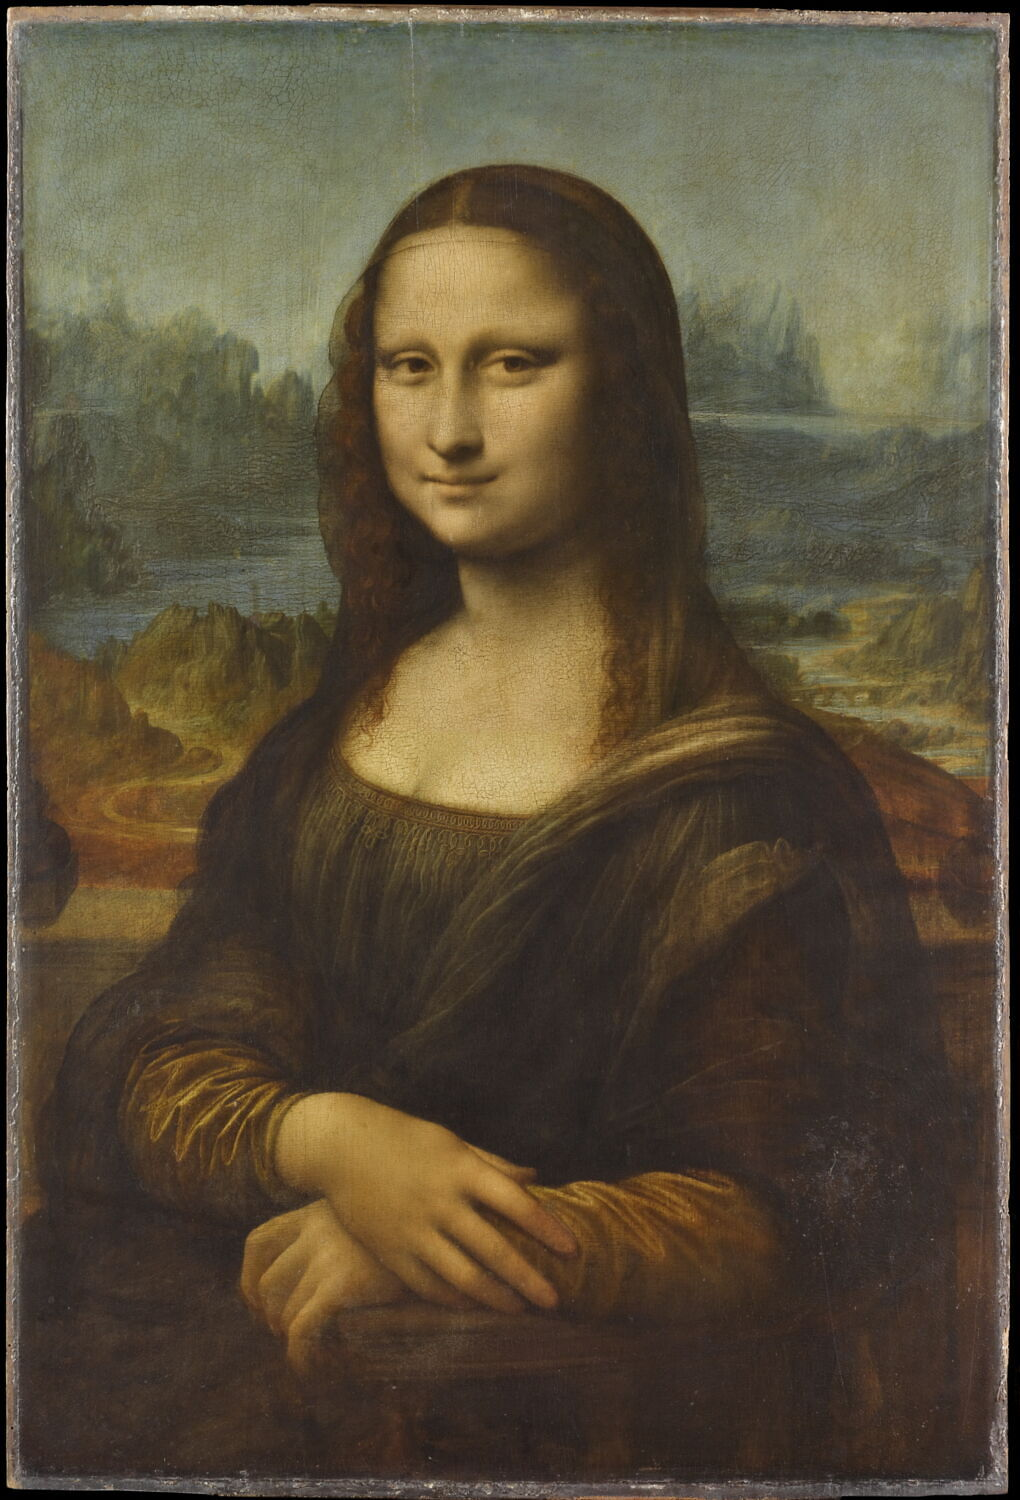
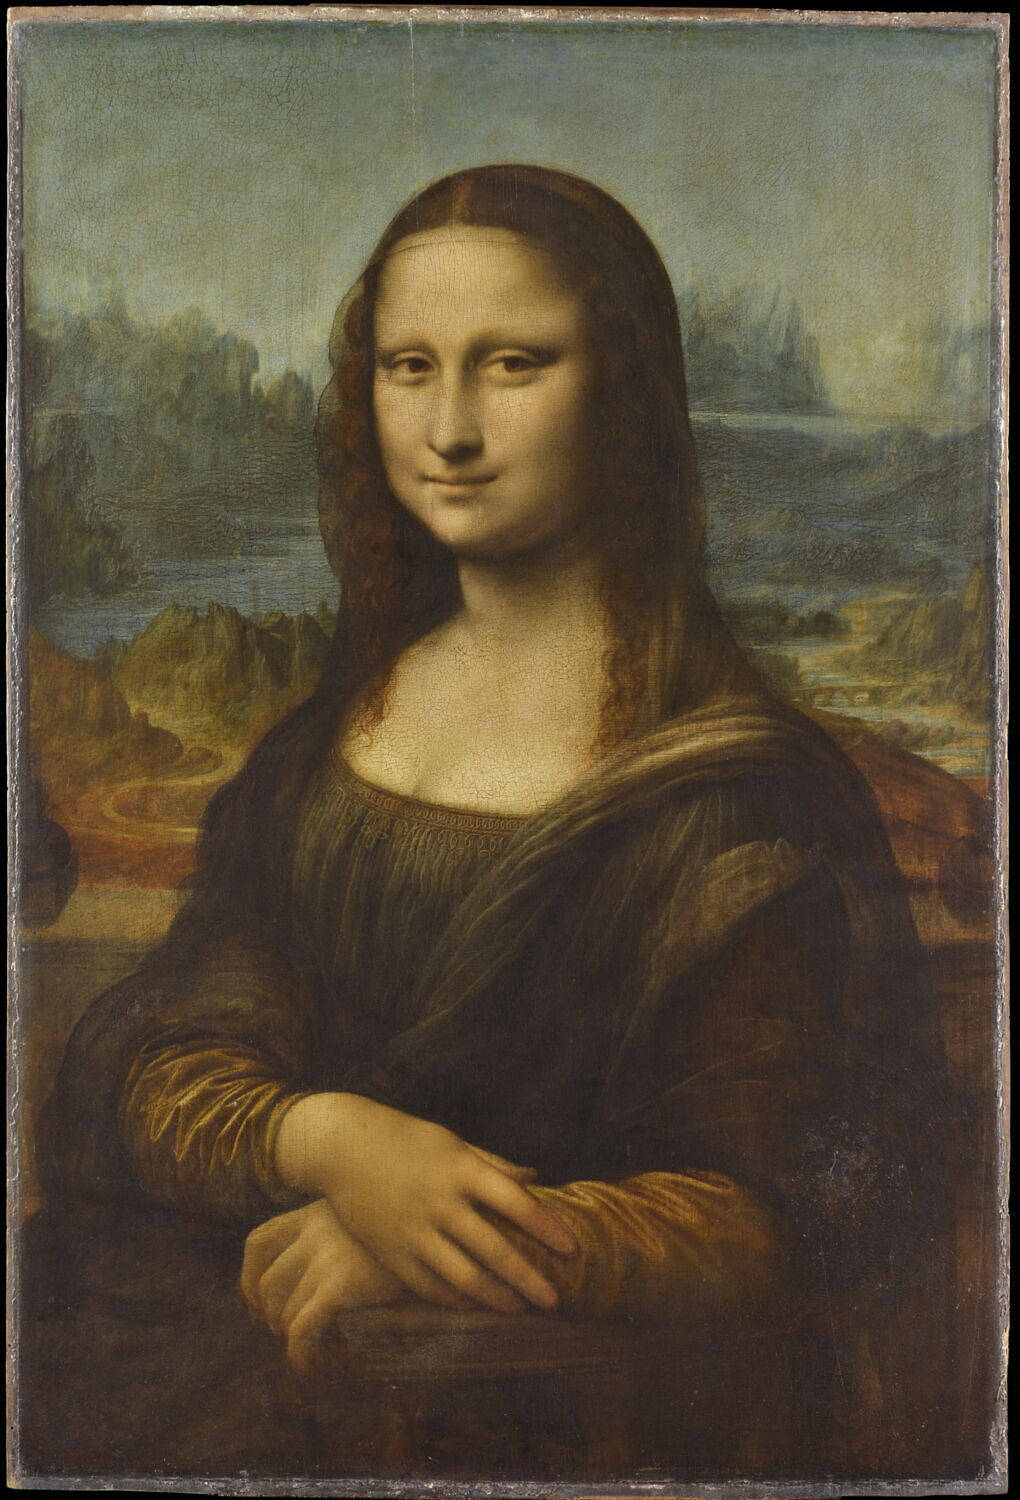

In [12]:
show_comparison_pair()

收判断后运行本次绘画图像的像素与文件大小检验。

In [13]:
photo_evidence()

{'比较起点': '所提供JPEG本次解码的RGB像素；不证明更早原图无损',
 '未压缩RGB数据B': 4590000,
 '像素总数': 1530000,
 '结果': [{'文件': 'painting-source.png',
   '完整文件B': 1706860,
   '尺寸': (1020, 1500),
   '变化像素': 0,
   '回读像素一致': True},
  {'文件': 'painting-quality80.jpg',
   '完整文件B': 240848,
   '尺寸': (1020, 1500),
   '变化像素': 504742,
   '回读像素一致': False},
  {'文件': 'painting-quality20.jpg',
   '完整文件B': 73692,
   '尺寸': (1020, 1500),
   '变化像素': 1520212,
   '回读像素一致': False}]}

同坐标放大比较。


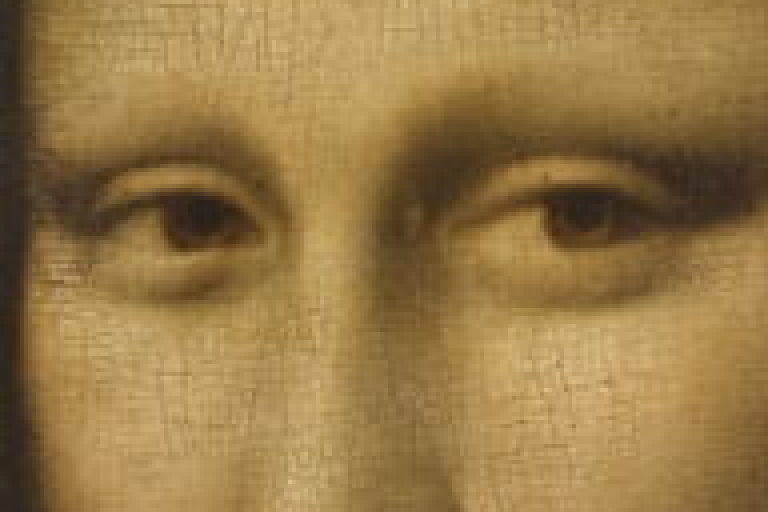
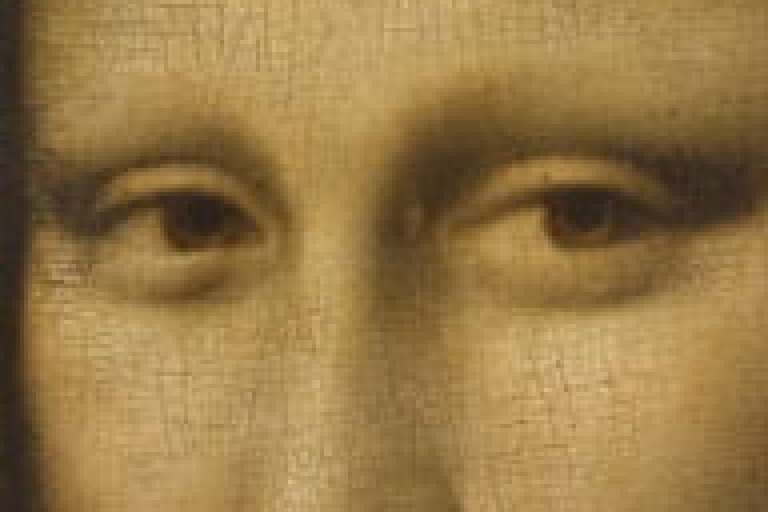

In [14]:
show_comparison_pair(detail=True)

可选低质量对照；核心课赶时间时跳过。


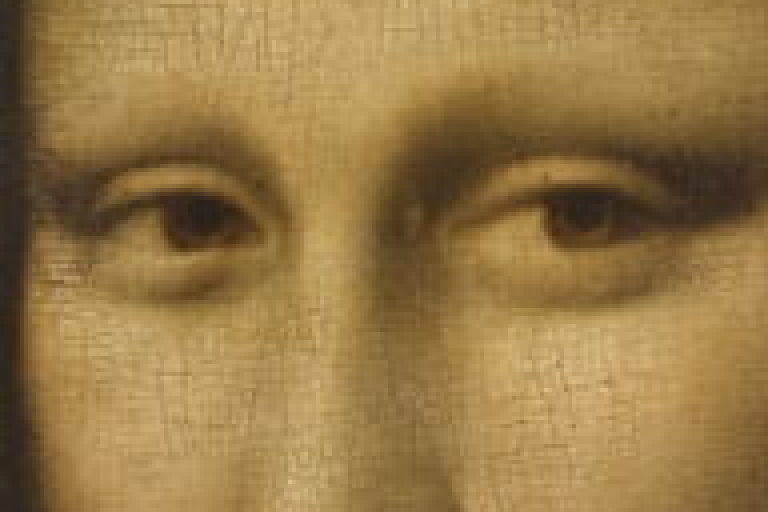
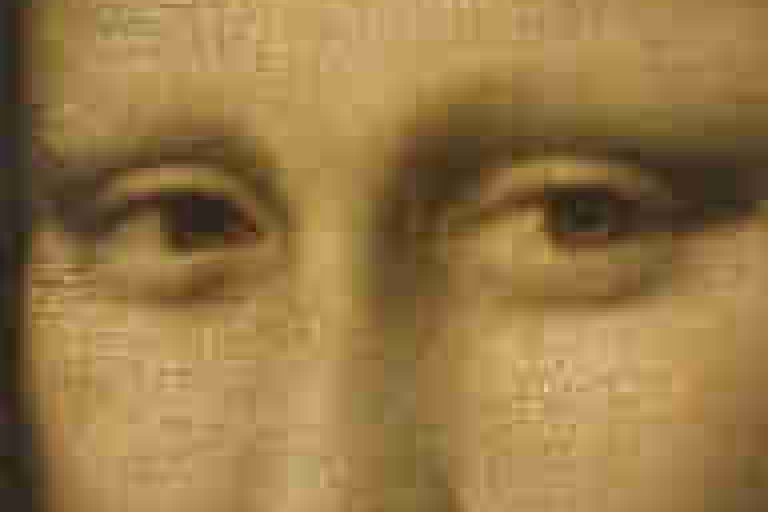

In [15]:
show_comparison_pair(detail=True, quality=20)

换成程序测试图，大小关系是否相同？

In [16]:
image_evidence()

{'未压缩RGB数据B': 248832,
 '像素总数': 82944,
 '结果': [{'文件': 'test-source.png',
   '完整文件B': 4441,
   '尺寸': (384, 216),
   '变化像素': 0,
   '回读像素一致': True},
  {'文件': 'test-quality80.jpg',
   '完整文件B': 10766,
   '尺寸': (384, 216),
   '变化像素': 28917,
   '回读像素一致': False},
  {'文件': 'test-quality20.jpg',
   '完整文件B': 6752,
   '尺寸': (384, 216),
   '变化像素': 66885,
   '回读像素一致': False}]}

可选：改quality并实测，只保存到demos/scratch。

In [17]:
save_jpeg_trial(quality=80)

{'quality': 80,
 '完整文件B': 240848,
 '回读像素一致': False,
 '路径': '/Users/chran/repo/shtick/1-2-encoding/1-2-4-data-compresson/demos/scratch/trial-quality80.jpg'}

### 阶段小结：Q7之后

起点加差值为何可逆？两个原数同归120为何不可逆？

这组问题让我学会：________________

对应主枝：为何压缩／怎样变小／能否恢复／怎样选择（圈选）。

教师控制：先留8秒收学生归纳，再显示已学节点；30秒计入当前Q预算。感知相似，不能证明原值相同。

![此时已学知识树，红框为本轮新增节点。](assets/knowledge/tree-2.png)

## Q8 同一种误差，哪些任务能接受？

A3：通知少了日期，程序少了等号（输入60），照片为清楚的浏览副本。逐项判断并写理由。

判断与理由：________________

教师结论：通知／源程序本体必须无损；照片题给浏览副本可有损，但换读小字或测量要重评。

## Q9 看扩展名，就能判定压缩方式吗？

依据PNG像素检验与TIFF配置卡，改正‘所有图片压缩都有损’。JPG、TIF、MP3、MPEG分别要补什么条件？

判断与理由：________________

教师结论：常见JPG照片通常有损；TIF看编码；MP3常见有损音频；MPEG是相关标准组，常见视频编码有损。PNG是图片无损反例。

### 阶段小结：Q9之后

说出一类必须无损的数据，再给TIF补一条判断条件。

这组问题让我学会：________________

对应主枝：为何压缩／怎样变小／能否恢复／怎样选择（圈选）。

教师控制：先留8秒收学生归纳，再显示已学节点；30秒计入当前Q预算。媒体可以无损；接受有损需要质量达标。

![此时已学知识树，红框为本轮新增节点。](assets/knowledge/tree-3.png)

## Q10 怎样在大小限制和信息要求之间选方案？

A3题目给定结果：限额100KiB；程序A80KiB/完整恢复、B50KiB/删改；照片A110KiB/像素一致、B70KiB/主题清楚。两项任务分别选择，并检查大小与信息要求。

判断与理由：________________

教师结论：程序选A，照片选B。先收40秒出口，课后核对：解压结果vs原输入；外观相似不证明原值一致。

### 阶段小结：Q10之后

沿知识树说明：程序A、照片B分别通过了哪两项检查？

这组问题让我学会：________________

对应主枝：为何压缩／怎样变小／能否恢复／怎样选择（圈选）。

教师控制：先留8秒收学生归纳，再显示已学节点；30秒计入当前Q预算。空间更少，还要符合当前任务的信息要求。

![此时已学知识树，红框为本轮新增节点。](assets/knowledge/tree-4.png)

## 出口检查

无损判断要比较________与________。

照片看不出变化仍可能有损，因为________。

## 第二课时可选：帧间变化

先预测：保存帧一之后，帧二要更新哪些格？一个2×2块右移一格。不是只保存新位置；旧位置还要清除。此模型不是完整MPEG码流。

In [18]:
video_changes()

{'帧一': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 '帧二': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 '更新': [(10, 0), (12, 1), (18, 0), (20, 1)],
 '变化格数': 4,
 '完整恢复': True}

## D6音频拓展的实施边界

核心45分钟不做音频试听。本包未提供经统一增益、时延对齐的MP3听辨样本。第二课时若做D6，按course-design.qmd的8秒44.1kHz/16bit单声道PCM→128/32kbps规格，用同一源文件各编码一次，记录编码器、增益和时延；不得把音量差当作压缩差。来源与技术边界见课程设计C7。